# AA_Cam_pose_estimate_batches

Batch harness: send one video's frames through every reconstruction technique (VGGT, VGGT-Omega, MegaSaM, CUT3R, lingbot-map), align each technique's camera trace against a GPS ground-truth trace, and collect RMSE/mean_dist/runtime into one results table instead of separate pairwise chart images (see `AA_CAM_POSE_COMPARE_01.ipynb` for the older pairwise-only version).

Cells reused near-verbatim from `ZZ_MASTER_SWITCH_V03.ipynb`/`AJ_lingbotmap.ipynb` where noted.

In [6]:
%load_ext autoreload
%autoreload 2

## Config

In [ ]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

# Find the repo root by walking up until we hit src/A_Config.py, rather than
# trusting cwd -- VS Code's Jupyter kernel cwd is often the workspace root, not
# this notebook's own folder, and inside the Singularity container cwd is the
# bind-mount root (/workspace) directly, not Experiments/. Both broke
# Path.cwd().parent this session; this walk-up is robust to either.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
print("project_root:", project_root)

from A_Config import (
    set_case, case_dir, frames_for_recon_dir, lingbot_map_dir,frames_for_cam_poses_dir,
    vggt_o_output_dir, predictions_path, cut3r_output_dir, reg_dir, FRAME_NAME_FMT,
)

case_name = "07_Tropea_cafe"
experiment = "Cat_walk"
set_case(case_name, experiment)

# One shared frame set used by every technique, so the comparison is apples-to-apples.
# NOTE: CUT3R can't handle big recons (per AJ_lingbotmap.ipynb's own comment) -- keep
# this under ~200 frames if CUT3R is enabled below.
frames_for_recon = frames_for_cam_poses_dir()
print("frames_for_recon:", frames_for_recon)

out_dir = case_dir() / "080_Experiments"
out_dir.mkdir(parents=True, exist_ok=True)

runtimes = {}  # technique -> minutes (decimal), filled in by each runner cell below

FLAGS = {
    "CUT3R_RECON":     True,
    "MEGA_SAM_RECON":  False,
    "VGGT_RECON":      False,
    "VGGT_O_RECON":    True,
    "LINGBOT_MAP_RECON": True,
    "REALITYSCAN_RECON": False,
    "FRAME_SELECTION": False,

}

## Ground truth

Manually set for now -- eventually GT files will follow a `{case_name}_{experiment}_lat_lon_gt.csv` convention, but that naming isn't real on disk yet, so this stays an explicit variable rather than guessed automation.

`GPS_tags.csv` format: columns `Frame` (e.g. `"1661.jpg"`), `lat`, `lon` -- sparse, manually curated keyframe-to-GPS anchors, not one row per video frame.

In [8]:
# TODO: once GT files follow the case_experiment_lat_lon_gt.csv convention,
# derive this automatically instead of setting it by hand.
gt_csv_path = case_dir() / "000_GPS_Data" / "GPS_tags.csv"

from Q_GPS_processing import csv_to_GPS_dict
GPS_dict = csv_to_GPS_dict(gt_csv_path)
print(f"{len(GPS_dict)} GT anchors loaded from {gt_csv_path.name}")

29 GT anchors loaded from GPS_tags.csv


FRAMES

In [ ]:
#

In [ ]:
#FRAME SELECTION - Frame selection to make the cam poses
if FRAME_SELECTION == True:
    # Parameters
    fps = 30.07
    interval     = 25/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
    window       = 15     # search window for sharpness
    min_sharp    = 0.0    # raise this after inspecting selection_log.json
    res          =   CUT3R_size # resolution

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from B_video_processing import image_sequencer

    results = image_sequencer(
        #video_path    = str(video_path),
        video_path = str(video_path),
        output_dir    = str(frames_for_cam_poses),
        #res           = res,
        interval_sec  = interval,
        search_window = window,
        min_sharpness = min_sharp,
        start_frame  = start_3D_recon,
        end_frame    = end_3D_recon
    )

    print(f"\n{len(results)} frames written to {frames_for_recon}")
    FRAME_SELECTION = False
else:
    print("Cell disabled")

## CUT3R

In [9]:
if FLAGS["CUT3R_RECON"]:
    from run_models.E_cut3r_recon import run_cut3r

    t0 = time.perf_counter()
    run_cut3r(
        frames_dir=frames_for_recon,
        output_dir=cut3r_output_dir(),
        ckpt_path=project_root / "Models" / "CUT3R" / "src" / "cut3r_512_dpt_4_64.pth",
        render_3rdperson=False,
    )
    runtimes["CUT3R"] = (time.perf_counter() - t0) / 60  # decimal minutes
else:
    print("Cell disabled")

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
Loading model...
... loading model from /cs/student/project_msc/2025/cgvi/dbarker/Models/CUT3R/src/cut3r_512_dpt_4_64.pth
instantiating : ARCroco3DStereo(ARCroco3DStereoConfig(freeze='encoder',state_size=768,state_pe='2d',pos_embed='RoPE100',rgb_head=True,pose_head=True,patch_embed_cls='PatchEmbedDust3R',img_size=(512,512),head_type='dpt',output_mode='pts3d+pose',depth_mode=('exp',-inf,inf),conf_mode=('exp',1,inf),pose_mode=('exp',-inf,inf),enc_embed_dim=1024,enc_depth=24,enc_num_heads=16,dec_embed_dim=768,dec_depth=12,dec_num_heads=12,landscape_only=False))
<All keys matched successfully>
278 frames  →  /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk


CUT3R:   0%|                                            | 0/278 [00:00<?, ?it/s]/cs/student/project_msc/2025/cgvi/dbarker/Models/CUT3R/src/dust3r/heads/dpt_head.py:217: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/cs/student/project_msc/2025/cgvi/dbarker/Models/CUT3R/src/dust3r/heads/dpt_head.py:226: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
CUT3R: 100%|██████████████████████████████████| 278/278 [00:47<00:00,  5.90it/s]


State saved → /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk/cut3r_state.pt
Done. 278 frames in 0.8 min  (0.17 s/frame)
Output: /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk


In [10]:
if FLAGS["CUT3R_RECON"]:
    from run_models.E_cut3r_recon import run_cut3r

    t0 = time.perf_counter()
    run_cut3r(
        frames_dir=frames_for_recon,
        output_dir=cut3r_output_dir()/"revisit",
        ckpt_path=project_root / "Models" / "CUT3R" / "src" / "cut3r_512_dpt_4_64.pth",
        render_3rdperson=False,
        revisit = True
    )
    runtimes["CUT3R_Revisit"] = (time.perf_counter() - t0) / 60  # decimal minutes
else:
    print("Cell disabled")

Loading model...
... loading model from /cs/student/project_msc/2025/cgvi/dbarker/Models/CUT3R/src/cut3r_512_dpt_4_64.pth
instantiating : ARCroco3DStereo(ARCroco3DStereoConfig(freeze='encoder',state_size=768,state_pe='2d',pos_embed='RoPE100',rgb_head=True,pose_head=True,patch_embed_cls='PatchEmbedDust3R',img_size=(512,512),head_type='dpt',output_mode='pts3d+pose',depth_mode=('exp',-inf,inf),conf_mode=('exp',1,inf),pose_mode=('exp',-inf,inf),enc_embed_dim=1024,enc_depth=24,enc_num_heads=16,dec_embed_dim=768,dec_depth=12,dec_num_heads=12,landscape_only=False))
<All keys matched successfully>
278 frames  →  /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk/revisit


CUT3R: 100%|██████████████████████████████████| 278/278 [00:21<00:00, 12.91it/s]


Pass 2 (revisiting): re-processing all frames with frozen final state...


revisit: 100%|████████████████████████████████| 278/278 [00:51<00:00,  5.45it/s]


Revisit pass done. 278 frames in 0.9 min  (0.18 s/frame)
State saved → /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk/revisit/cut3r_state.pt
Done. 278 frames in 1.2 min  (0.26 s/frame)
Output: /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk/revisit


## MegaSaM

In [11]:
if FLAGS["MEGA_SAM_RECON"]:
    from run_models.E_megasam_recon import run_megasam

    megasam_output_dir = case_dir() / "036_MEGASAM_output" / experiment
    megasam_output_dir.mkdir(parents=True, exist_ok=True)

    t0 = time.perf_counter()
    megasam_npz_path = run_megasam(
        frames_dir=frames_for_recon,
        output_dir=megasam_output_dir,
        mega_sam_dir=project_root / "Models" / "mega-sam",
        scene_name=case_name,
    )
    runtimes["MegaSaM"] = (time.perf_counter() - t0) / 60
else:
    print("Cell disabled")

Cell disabled


## VGGT (plain)

In [12]:
vggt_output_dir = case_dir() / "034_VGGT_output" / experiment

In [13]:
if FLAGS["VGGT_RECON"]:
    import argparse
    sys.path.insert(0, str(project_root / "Models" / "VGGT" / "vggt"))
    from demo_colmap import demo_fn

    vggt_output_dir = case_dir() / "034_VGGT_output" / experiment

    vggt_args = argparse.Namespace(
        scene_dir=str(case_dir()),
        image_dir=str(frames_for_recon),
        output_dir=str(vggt_output_dir),
        max_frames=500,
        load_resolution=128,
        seed=42,
        use_ba=False,
        max_reproj_error=8.0,
        shared_camera=False,
        camera_type="SIMPLE_PINHOLE",
        vis_thresh=0.2,
        query_frame_num=8,
        max_query_pts=4096,
        fine_tracking=True,
        conf_thres_value=5.0,
    )

    t0 = time.perf_counter()
    demo_fn(vggt_args)
    runtimes["VGGT"] = (time.perf_counter() - t0) / 60
else:
    print("Cell disabled")

Cell disabled


## VGGT-Omega

In [14]:
if FLAGS["VGGT_O_RECON"]:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    from run_models.E_VGGT_omega import run_vggt_omega

    t0 = time.perf_counter()
    run_vggt_omega(
        image_dir=str(frames_for_recon),
        output_dir=str(vggt_o_output_dir()),
        checkpoint_path=str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_dir=str(project_root / "Models" / "vggt-omega"),
        image_resolution=256,
        conf_thres=20.0,
        max_points=0,
        show_cam=True,
    )
    runtimes["VGGT-Omega"] = (time.perf_counter() - t0) / 60
else:
    print("Cell disabled")

278 frames  →  /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_VGGT_O_output/Cat_walk
Saved: /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_VGGT_O_output/Cat_walk/predictions.npz
Saved: /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_VGGT_O_output/Cat_walk/scene.glb


## lingbot-map

In [15]:
if FLAGS["LINGBOT_MAP_RECON"]:
    from B_lingbot_map import run_lingbot_map

    t0 = time.perf_counter()
    run_lingbot_map()
    runtimes["lingbot-map"] = (time.perf_counter() - t0) / 60
else:
    print("Cell disabled")

AttributeError: module 'demo' has no attribute 'build_parser'

## RealityScan

Requires RealityScan for Linux (Wine build) installed under `Tools/RealityScan/`
(not committed -- see `.gitignore`). Alignment/export CLI flags are TODOs in
`run_models/E_realityscan_recon.py` pending confirmation against RealityScan's
CLI docs -- don't enable this flag until those are checked.

In [ ]:
if FLAGS["REALITYSCAN_RECON"]:
    from run_models.E_realityscan_recon import run_realityscan

    t0 = time.perf_counter()
    csv_path = run_realityscan(
        frames_dir=frames_for_recon,
        output_dir=reg_dir() / "Registration_reality_scan",
        rs_exe=project_root / "Tools" / "RealityScan" / "RealityScan.exe",
    )
    runtimes["RealityScan"] = (time.perf_counter() - t0) / 60
else:
    print("Cell disabled")

## Batch comparison

For each technique that ran: build `{frame: position}`, match against the sparse GT anchors, Umeyama-align, and score.

`rmse`/`mean_dist` are the primary, trustworthy numbers -- raw metres, no normalization, sort the table by `rmse`. Everything else is secondary context, kept for cross-video comparison but not validated as a difficulty measure:

- **`n_points`** -- caveat on `rmse` itself: too few correspondence points can produce a deceptively low RMSE from an underconstrained Umeyama fit, not genuinely good alignment.
- **`trajectory_length` / `spatial_extent` / `rmse_cm_per_m`** -- two different attempts to normalize RMSE for cross-video comparability, both falsified as general difficulty proxies: `trajectory_length` breaks on near-stationary sequences (ratio blows up on a near-zero denominator despite that being a genuinely hard, low-parallax case); `spatial_extent` breaks on the straight-line-vs-orbit case (walking straight at a subject gives *larger* extent but *worse* reconstruction than orbiting it at a fixed radius, because extent doesn't capture angular/parallax diversity relative to the scene -- see `spatial_extent`'s docstring below). The theoretically correct measure is angular diversity/observation count **per reconstructed 3D point**, not per camera position, which needs correspondence data this notebook doesn't currently compute. Reported for context, not as ranking criteria.

{1661: array([ 0.00165716, -0.00118932, -0.00036418], dtype=float32), 1687: array([-0.18789843, -0.0138352 ,  0.10234905], dtype=float32), 1700: array([-0.19820522, -0.01115026,  0.07904308], dtype=float32), 1725: array([-0.14133158, -0.015325  ,  0.07607706], dtype=float32), 1750: array([-0.24016197, -0.03924938,  0.21897304], dtype=float32), 1775: array([-0.2772369 , -0.02790665,  1.104261  ], dtype=float32), 1800: array([-0.47376704, -0.0563632 ,  1.7568245 ], dtype=float32), 1825: array([-0.60481805, -0.08386918,  2.242946  ], dtype=float32), 1850: array([-0.8438393, -0.1285785,  2.9242682], dtype=float32), 1875: array([-0.9266952 , -0.13228841,  3.5387595 ], dtype=float32), 1900: array([-1.0840232 , -0.15484425,  4.1777186 ], dtype=float32), 1923: array([-1.3070399 , -0.20638083,  4.6617928 ], dtype=float32), 1947: array([-1.2962044 , -0.09458426,  3.4444027 ], dtype=float32), 1966: array([-1.6786686 , -0.08916826,  4.130757  ], dtype=float32), 2000: array([-1.5818915 , -0.1480690

,technique,rmse,mean_dist,n_points,trajectory_length,spatial_extent,rmse_cm_per_m,runtime_minutes
0,VGGT-Omega,2.371530,2.184140,29,103.465778,32.418749,2.292091,None
1,lingbot-map,2.412880,2.040972,29,103.465778,32.418749,2.332056,None
2,CUT3R,12.272886,10.915234,29,103.465778,32.418749,11.861783,None


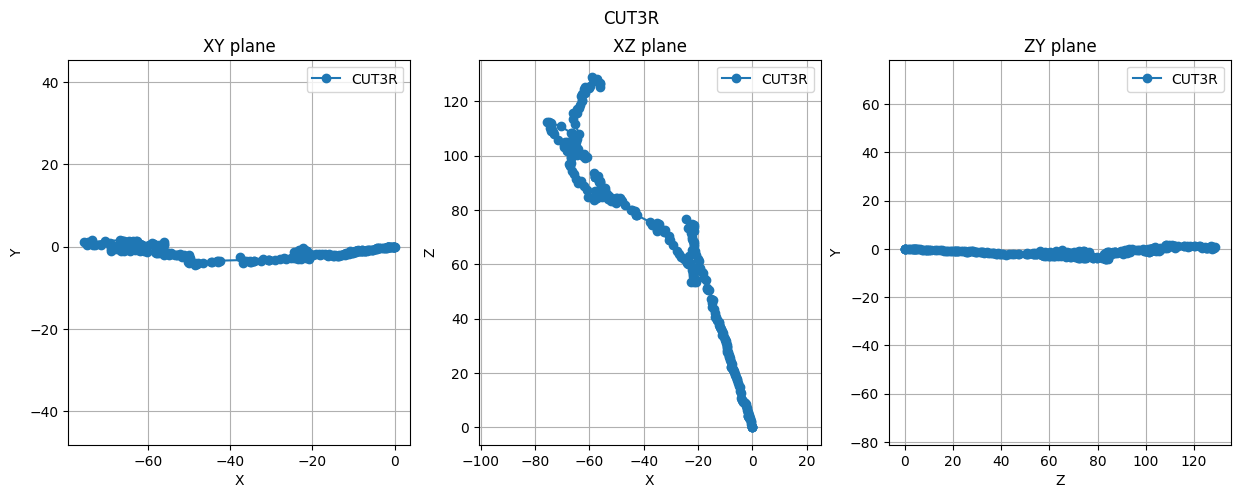

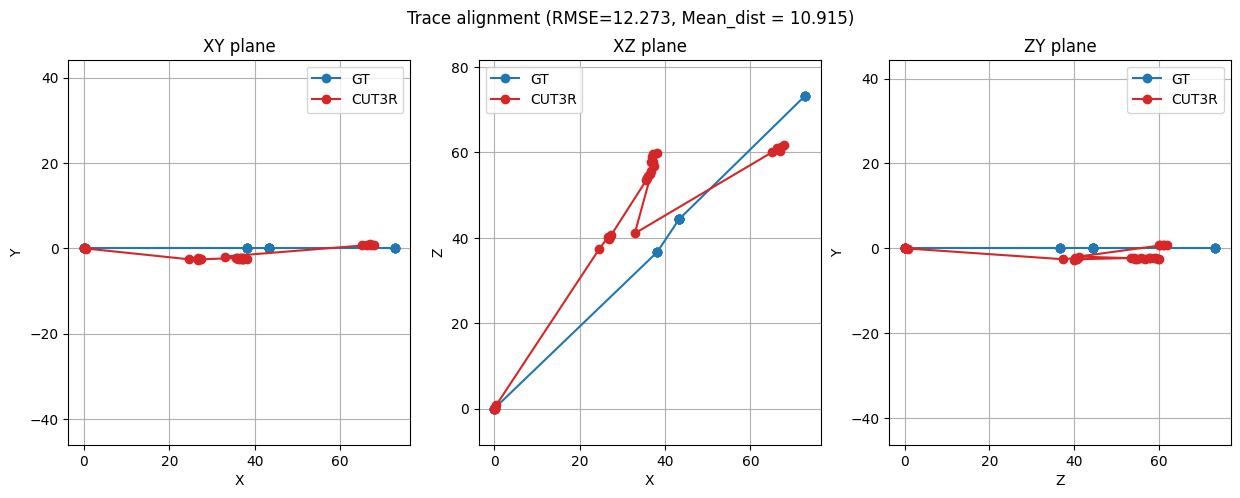

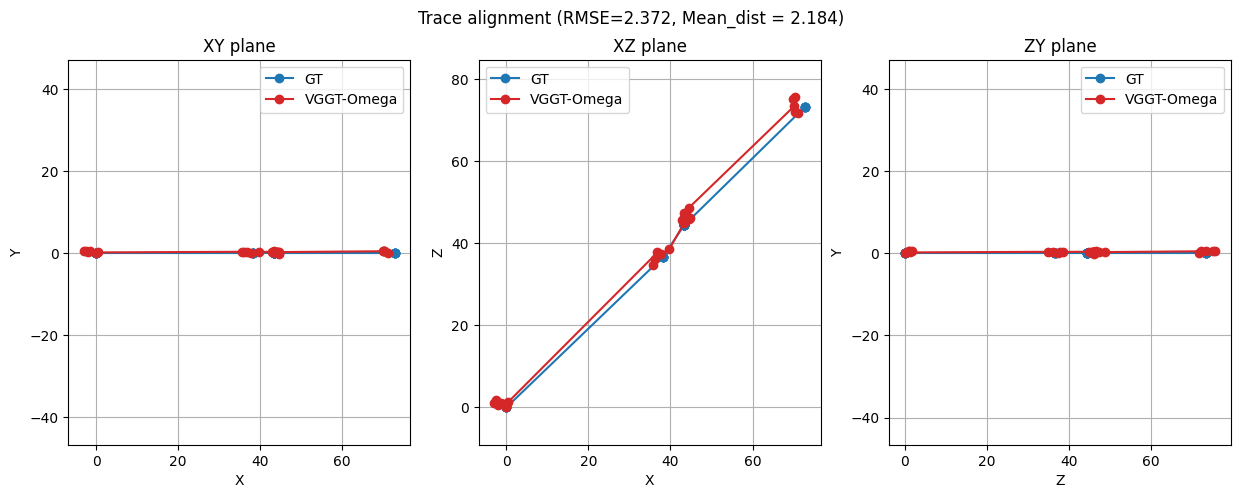

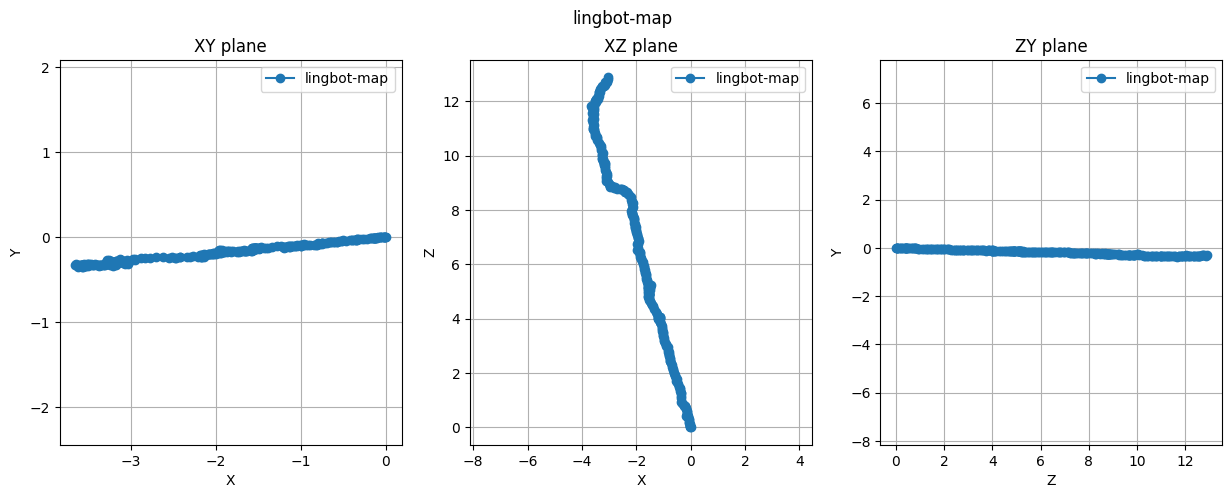

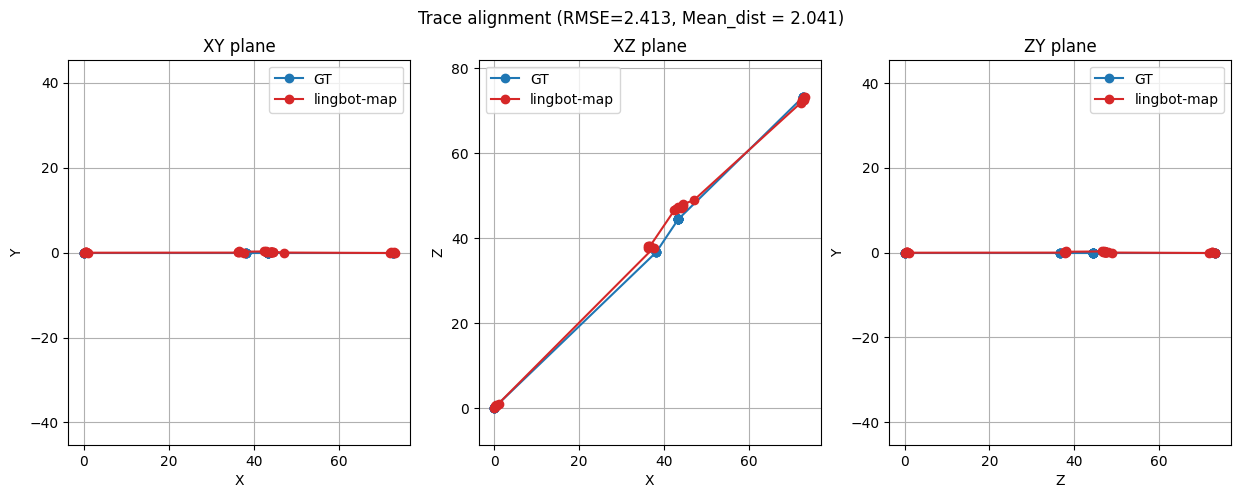

In [ ]:
from F_post_recon_processing import (
    Reconstruction, load_cut3r_trace_v2, load_megasam_trace, load_VGGT_trace,
    load_lingbot_map_trace, positions_to_frame_dict,
)
from Q_Metric_georeferencing import GPS_camerapose_matcher
from G_transforms_alignments import umeyama_align


def trajectory_length(positions):
    """Path length -- distance actually travelled, sensitive to drift accumulation."""
    return float(np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1)))


def spatial_extent(positions):
    """Radius of gyration of the camera positions. NOT a reliable reconstruction-
    difficulty proxy on its own -- falsifiable by counterexample: walking straight
    at a subject gives LARGE extent (positions spread over a line) but WORSE
    reconstruction (near-collinear viewpoints, little angular/parallax diversity
    relative to the subject -- a classic degenerate SfM baseline configuration);
    orbiting the same subject at a fixed radius gives MODERATE extent but usually
    BETTER reconstruction (maximal angular diversity, many viewpoints converging
    on the same structure). What actually matters is angular coverage relative to
    scene content, which isn't computable from camera positions alone -- it needs
    to know where the scene content is. Reported as honest context, not as a
    trustworthy difficulty signal -- don't infer "harder" or "easier" from this
    number alone."""
    centroid = positions.mean(axis=0)
    return float(np.sqrt(np.mean(np.sum((positions - centroid) ** 2, axis=1))))


def align_and_score(technique, world_pos_dict, runtime_minutes):
    GPS_locs, lat_0, lon_0, object_locs = GPS_camerapose_matcher(GPS_dict, world_pos_dict)
    R, s, t, B_aligned, rmse = umeyama_align(
        GPS_locs, object_locs, label_A="GT", label_B=technique,
        out_path=out_dir / f"{case_name}_{experiment}_{technique}_align.png",
        anchor_index=0,
    )
    mean_dist = float(np.mean(np.linalg.norm(GPS_locs - B_aligned, axis=1)))
    traj_len = trajectory_length(GPS_locs)
    return {
        # --- primary, trustworthy stats -- everything below this line is
        # context/normalization attempts for cross-video comparison, not to be
        # taken as more authoritative than these two raw numbers ---
        "technique": technique,
        "rmse": rmse,
        "mean_dist": mean_dist,
        "n_points": len(GPS_locs),
        # --- secondary context: attempts to make traces comparable across
        # videos of different length/shape. Two position-only normalizations
        # were tried and both have known failure modes (see docstrings above).
        # The theoretically correct difficulty measure is angular diversity
        # (triangulation angle) or observation count PER RECONSTRUCTED 3D POINT,
        # not per camera position -- but that needs per-point visibility/
        # correspondence data across frames, a much heavier computation this
        # notebook doesn't currently do. Reported for context, not as ranking
        # criteria. ---
        "trajectory_length": traj_len,
        "spatial_extent": spatial_extent(GPS_locs),
        "rmse_cm_per_m": 100 * rmse / traj_len if traj_len > 0 else float("nan"),
        "runtime_minutes": runtime_minutes,
    }


results = []

if FLAGS["CUT3R_RECON"]:
    _, world_pos_dict = load_cut3r_trace_v2(cut3r_output_dir() / "camera")
    results.append(align_and_score("CUT3R", world_pos_dict, runtimes.get("CUT3R")))

if FLAGS["MEGA_SAM_RECON"]:
    positions = load_megasam_trace(megasam_npz_path)
    world_pos_dict = positions_to_frame_dict(positions, frames_for_recon, FRAME_NAME_FMT)
    results.append(align_and_score("MegaSaM", world_pos_dict, runtimes.get("MegaSaM")))

if FLAGS["VGGT_RECON"]:
    positions = load_VGGT_trace(vggt_output_dir)
    world_pos_dict = positions_to_frame_dict(positions, frames_for_recon, FRAME_NAME_FMT)
    results.append(align_and_score("VGGT", world_pos_dict, runtimes.get("VGGT")))

if FLAGS["VGGT_O_RECON"]:
    recon = Reconstruction.load(frames_for_recon, predictions_path(), FRAME_NAME_FMT)
    world_pos_dict = recon.cam_pos_dict()
    results.append(align_and_score("VGGT-Omega", world_pos_dict, runtimes.get("VGGT-Omega")))

if FLAGS["LINGBOT_MAP_RECON"]:
    _, world_pos_dict = load_lingbot_map_trace(lingbot_map_dir())
    results.append(align_and_score("lingbot-map", world_pos_dict, runtimes.get("lingbot-map")))

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)  # raw RMSE, the pure stat -- not a normalized/fudged one
results_df

## Combined across videos

Re-run this whole notebook per video, appending each run's `results_df` to a growing CSV, then summarize here. Raw `rmse` is the pure stat; `rmse_cm_per_m` is shown alongside as a secondary, imperfect attempt at cross-video comparability (see the batch-comparison cell's caveats -- it's not a validated difficulty measure, just the least-bad normalization tried so far). With very few videos this is just an average of 1-2 numbers -- not meaningful yet on its own, but the aggregation is correct and ready to use once more videos accumulate. Once there are enough videos (~6+), consider average-rank-per-video instead of raw-mean (scale-invariant across videos of differing difficulty), and Friedman+Nemenyi if a statistical-significance comparison between techniques is needed -- plain Wilcoxon is pairwise-only and wants more paired samples (videos) than we'll have for a while to mean much.

In [ ]:
all_results_path = out_dir / "all_videos_results.csv"

combined = results_df.copy()
combined.insert(0, "case_name", case_name)
combined.insert(1, "experiment", experiment)

if all_results_path.exists():
    combined = pd.concat([pd.read_csv(all_results_path), combined], ignore_index=True)
combined.to_csv(all_results_path, index=False)

# raw rmse first (the pure stat), rmse_cm_per_m alongside as the (imperfect,
# see spatial_extent's docstring) attempt at cross-video comparability -- averaging
# raw rmse across videos of very different length/difficulty has its own distortion,
# so both are shown rather than picking one as definitively "the" combined number.
combined.groupby("technique")[["rmse", "rmse_cm_per_m"]].agg(["mean", "median", "count"])

rmse                  rmse_cm_per_m                 
                  mean     median count          mean     median count
technique                                                             
CUT3R        12.272886  12.272886     1     11.861783  11.861783     1
VGGT-Omega    2.371530   2.371530     1      2.292091   2.292091     1
lingbot-map   2.412880   2.412880     2      2.332056   2.332056     2